In [60]:
import numpy as np
import pandas as pd

In [61]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [62]:
df.shape

(10000, 3)

In [63]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [64]:
import seaborn as sns

<Axes: xlabel='Height', ylabel='Count'>

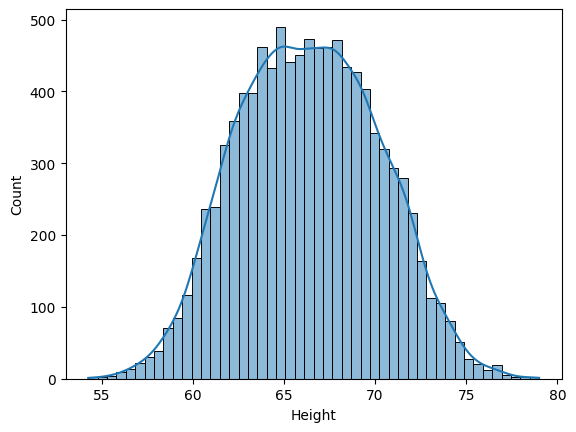

In [65]:
# sns.displot(df['Height'])
sns.histplot(df['Height'], kde=True)

<Axes: xlabel='Height'>

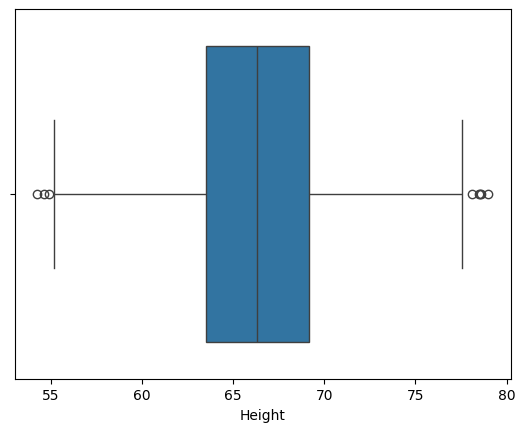

In [66]:
sns.boxplot(x= df['Height'])

In [67]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

74.7857900583366

In [68]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

58.13441158671655

In [69]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [70]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

/Users/aditya/Documents/ML/ML-Practice/Myenv/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


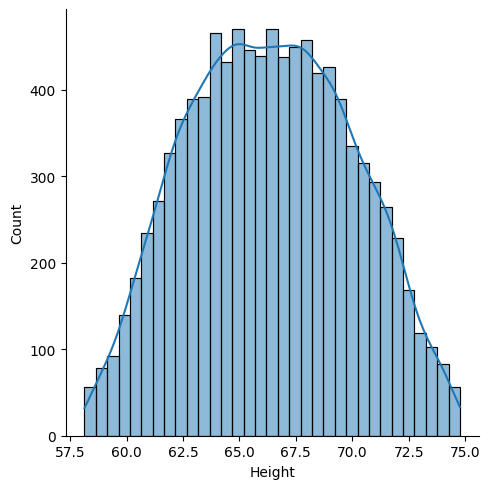

In [71]:
sns.displot(new_df['Height'], kde=True)

<Axes: xlabel='Height'>

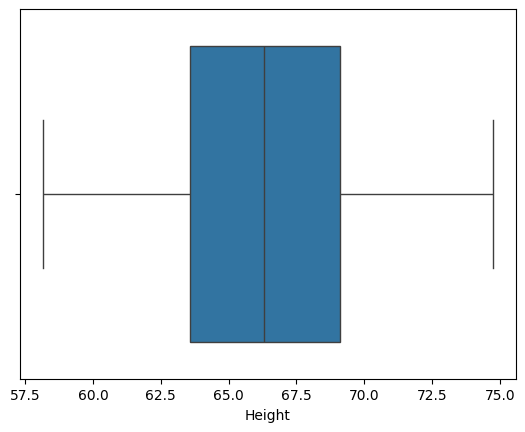

In [72]:
sns.boxplot(x = new_df['Height'])

# Capping or Winsorization

In [73]:
df['Height'] = np.where(df['Height'] >= upper_limit, upper_limit, np.where(df['Height'] <= lower_limit, lower_limit, df['Height']))

In [74]:
df.shape

(10000, 3)

In [75]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

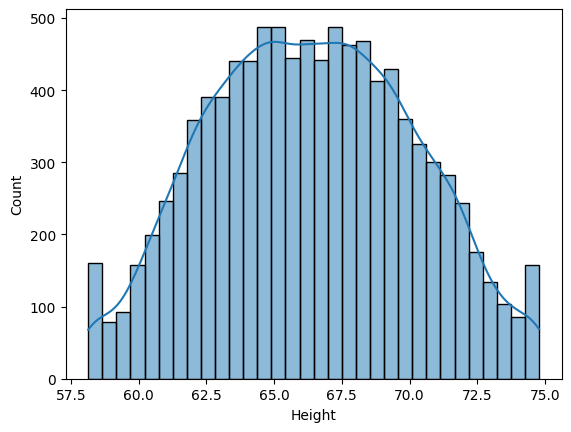

In [76]:
sns.histplot(df['Height'],kde=True)

<Axes: xlabel='Height'>

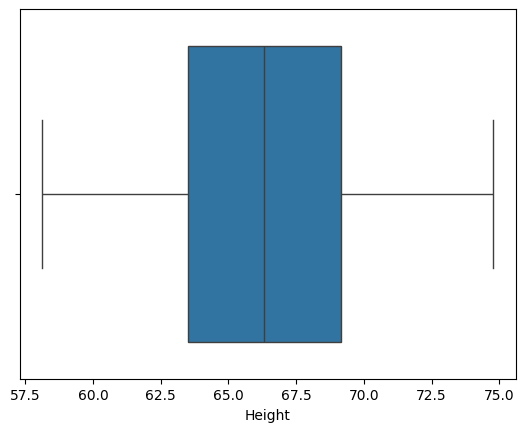

In [77]:
sns.boxplot(x= df['Height'])

# Winsorise with scipy method

In [78]:
from scipy.stats.mstats import winsorize
df2 = pd.read_csv('weight-height.csv')
arr = df2['Height'].to_numpy()
arr
winsorized_data = winsorize(arr, limits=[0.01, 0.01])

In [79]:
df2['Height'] = winsorized_data

In [80]:
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [81]:
df2.shape

(10000, 3)